In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Parameters
T = 5
r = 0.03
X0 = 10
gamma1 = 0.5

gamma2_values = [0.005, 0.01]

G = np.array([1.0, -0.5])

mu = np.array([0.12, 0.22])
theta = mu - r * np.ones(2)

# Volatility parameters
sigma1 = 0.16
sigma2 = 0.48
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [sigma2 * rho, sigma2 * np.sqrt(1 - rho**2)]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)

# Local mean-variance component
pi_MV = (1 / (gamma1 * X0)) * np.exp(-r * T) * Sigma_inv @ theta

rows=[]

# Brown investor
for i in range(2):
    rows.append({
        "Investor": "Brown",
        "Asset": f"Asset {i+1}",
        "Local MV": pi_MV[i],
        "ESG": np.nan,
        "Combined": pi_MV[i]
    })

# Green investors
for gamma2 in gamma2_values:
    pi_ESG = (gamma2 / (gamma1**2 * X0)) * np.exp(-r * T) * Sigma_inv @ G
    pi_green = pi_MV + pi_ESG

    for i in range(2):
        rows.append({
            "Investor": f"Green, gamma2={gamma2}",
            "Asset": f"Asset {i+1}",
            "Local MV": pi_MV[i],
            "ESG": pi_ESG[i],
            "Combined": pi_green[i]
        })

table = pd.DataFrame(rows)
print(table.round(4))

              Investor    Asset  Local MV     ESG  Combined
0                Brown  Asset 1    0.5715     NaN    0.5715
1                Brown  Asset 2    0.1248     NaN    0.1248
2  Green, gamma2=0.005  Asset 1    0.5715  0.0688    0.6403
3  Green, gamma2=0.005  Asset 2    0.1248 -0.0058    0.1190
4   Green, gamma2=0.01  Asset 1    0.5715  0.1376    0.7091
5   Green, gamma2=0.01  Asset 2    0.1248 -0.0116    0.1132


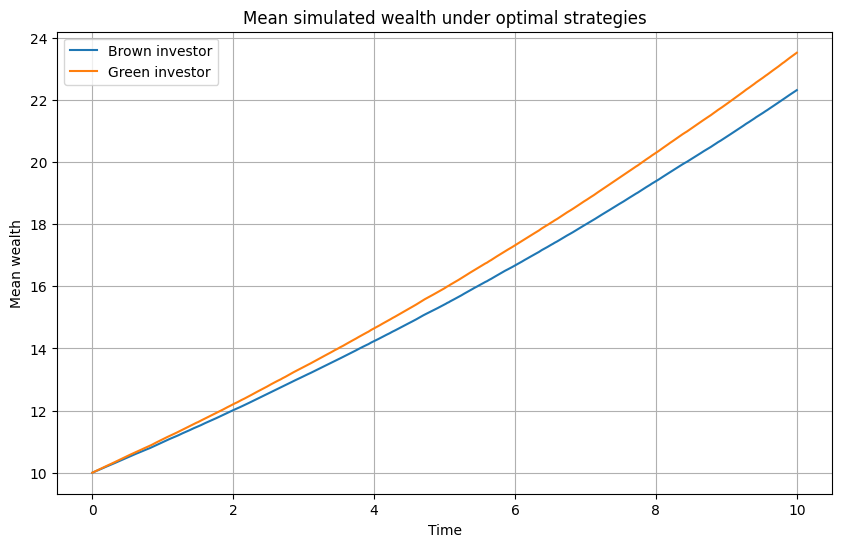

[[39.38149007 -1.1814447 ]
 [-1.1814447   4.37572112]]
[0.09 0.19]
[ 1.  -0.5]
2.9573311181682738


In [4]:
def simulate_wealth(X0,mu,sigma,gamma1,gamma2,Sigma,G,r,theta, T,Ndt,Nsims=100):
    dt=T/Ndt
    time = np.linspace(0,T,Ndt+1)

    X_b=np.zeros((Ndt+1,Nsims))
    X_g=np.zeros((Ndt+1,Nsims))

    X_b[0,:]=X0
    X_g[0,:]=X0

    Sigma_inv=np.linalg.inv(Sigma)

    for idx in range(Ndt):
        t=time[idx]

        #Optimal amount for brown investor
        u_b=(1/gamma1)*np.exp(-r*(T-t))*Sigma_inv@theta

        #Optimal amount for green investor
        u_g=((1/gamma1)*np.exp(-r*(T-t))*Sigma_inv@theta+(gamma2/gamma1**2)*np.exp(-r*(T-t))*Sigma_inv@G)

        Z=np.random.randn(2,Nsims)
        dW=np.sqrt(dt)*Z

        #Euler discretization
        X_b[idx+1,:]=(X_b[idx,:]+(r*X_b[idx,:]+u_b.T@theta)*dt+(u_b.T@sigma@dW))

        X_g[idx+1,:]=(X_g[idx,:]+(r*X_g[idx,:]+u_g.T@theta)*dt+(u_g.T@sigma@dW))

    return time, X_b,X_g


# Parameters
T = 10
Ndt=500
Nsims=10000
r = 0.03
X0 = 10
gamma1 = 0.5
gamma2=0.01

G = np.array([1, -0.5])

mu = np.array([0.12, 0.22])
theta = mu - r * np.ones(2)

# Volatility parameters
sigma1 = 0.16
sigma2 = 0.48
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [sigma2 * rho, sigma2 * np.sqrt(1 - rho**2)]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)

time, X_b, X_g=simulate_wealth(
    X0=X0,
    r=r,
    T=T,
    mu=mu,
    theta=theta,
    sigma=sigma,
    Sigma=Sigma,
    G=G,
    gamma1=gamma1,
    gamma2=gamma2,
    Ndt=Ndt,
    Nsims=Nsims
)

plt.figure(figsize=(10, 6))
plt.plot(time, X_b.mean(axis=1), label="Brown investor")
plt.plot(time, X_g.mean(axis=1), label="Green investor")
plt.xlabel("Time")
plt.ylabel("Mean wealth")
plt.title("Mean simulated wealth under optimal strategies")
plt.legend()
plt.grid(True)
plt.show()

print(Sigma_inv)
print(theta)
print(G)
print(G.T@Sigma_inv@theta)

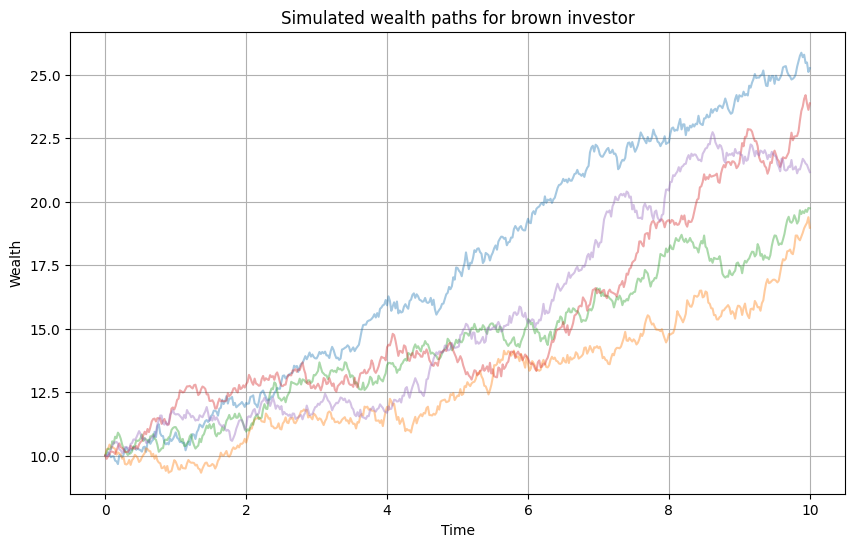

In [5]:
#Brown investor
np.random.seed(123)
plt.figure(figsize=(10, 6))

for i in range(5):
    plt.plot(time, X_b[:, i], alpha=0.4)

plt.xlabel("Time")
plt.ylabel("Wealth")
plt.title("Simulated wealth paths for brown investor")
plt.grid(True)
plt.show()

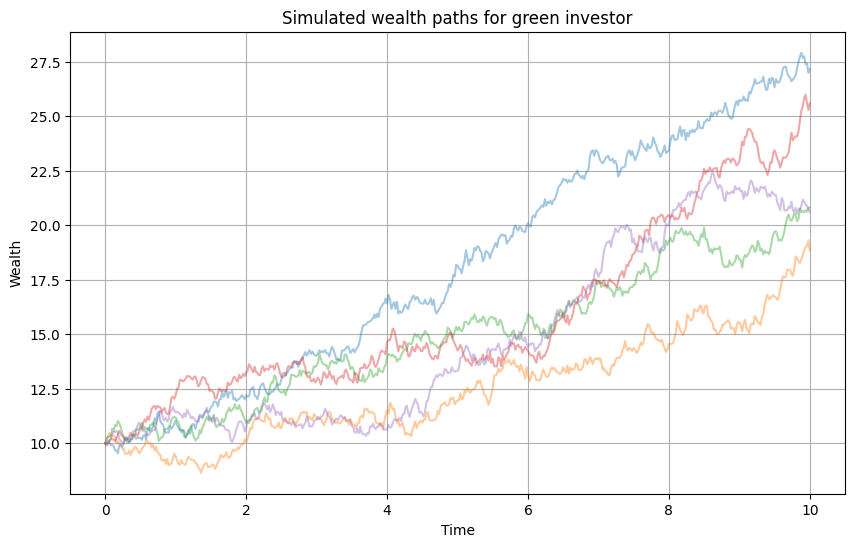

In [6]:
#Green investor
np.random.seed(123)
plt.figure(figsize=(10, 6))

for i in range(5):
    plt.plot(time, X_g[:, i], alpha=0.4)

plt.xlabel("Time")
plt.ylabel("Wealth")
plt.title("Simulated wealth paths for green investor")
plt.grid(True)
plt.show()

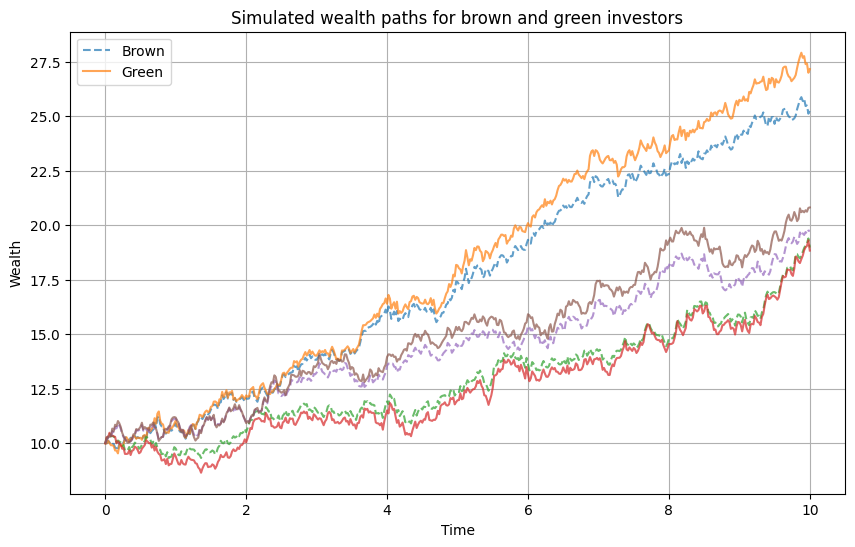

In [7]:
np.random.seed(123)
plt.figure(figsize=(10, 6))

for i in range(3):
    plt.plot(time, X_b[:, i], alpha=0.7, linestyle='--', label = "Brown" if i==0 else "")
    plt.plot(time, X_g[:, i], alpha=0.7, linestyle='-', label = "Green" if i==0 else "")

plt.xlabel("Time")
plt.ylabel("Wealth")
plt.title("Simulated wealth paths for brown and green investors")
plt.grid(True)
plt.legend()
plt.show()

<>:28: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:28: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/82/ncffm0295dg45nkclm8jp1kw0000gn/T/ipykernel_7215/567441026.py:28: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.plot(time, X_b[:,path],label="Brown investor, $\gamma_2=0$", color="brown")


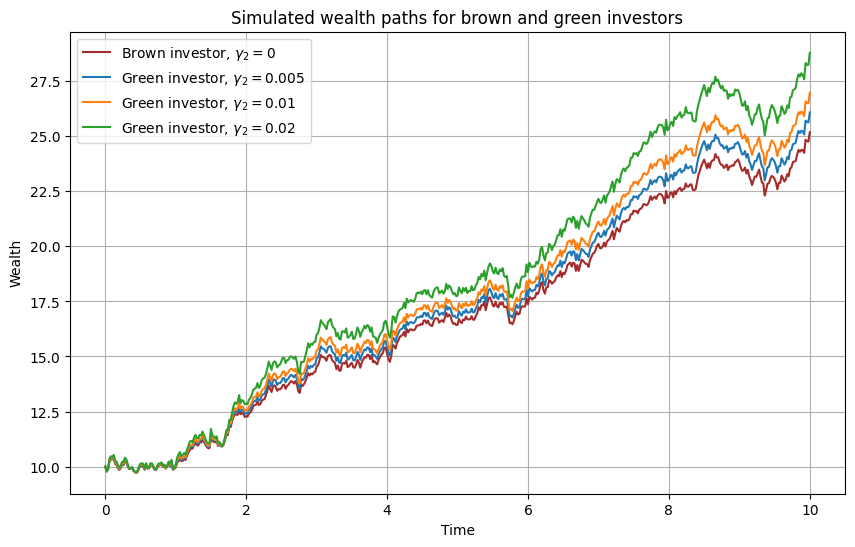

In [8]:
np.random.seed(123)

#Vary gamma2
gamma2_values=[0, 0.005, 0.01, 0.02]
path=0

plt.figure(figsize=(10, 6))

for gamma2_v in gamma2_values:
    np.random.seed(123)
    
    time, X_b, X_g=simulate_wealth(
    X0=X0,
    r=r,
    T=T,
    mu=mu,
    theta=theta,
    sigma=sigma,
    Sigma=Sigma,
    G=G,
    gamma1=gamma1,
    gamma2=gamma2_v,
    Ndt=Ndt,
    Nsims=Nsims,
)

    if gamma2_v==0:
        plt.plot(time, X_b[:,path],label="Brown investor, $\gamma_2=0$", color="brown")
    else:
        plt.plot(
            time,
            X_g[:, path],
            label = fr"Green investor, $\gamma_2={gamma2_v}$"
        )

plt.xlabel("Time")
plt.ylabel("Wealth")
plt.title("Simulated wealth paths for brown and green investors")
plt.grid(True)
plt.legend()
plt.show()

We now want to look at the optimal portfolios in terms of u. We want to plot $u_1^*(t)$ which is the monetary amount invested in asset 1 and $u_2^*(t)$ which is the amount invested in asset 2.

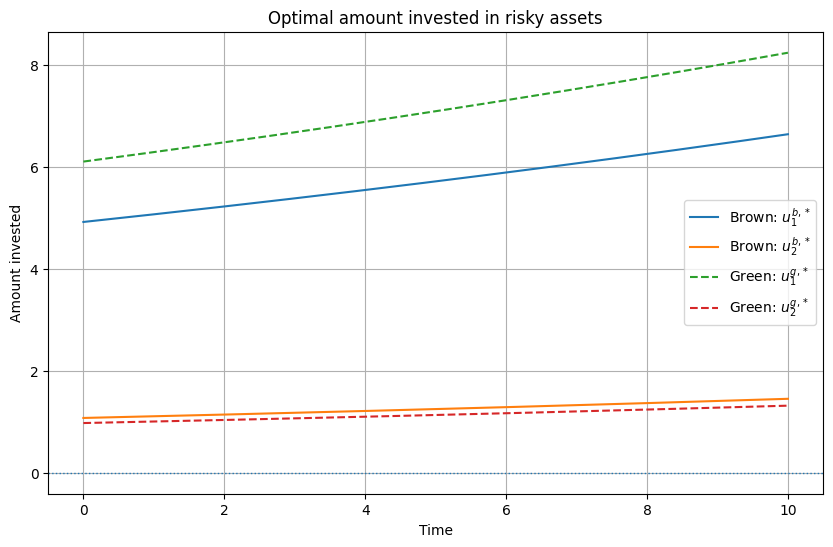

In [9]:
def optimal_u_brown(time, gamma1, r, T, Sigma, theta):
    Sigma_inv=np.linalg.inv(Sigma)

    u_values=[]

    for t in time:
        u_b=(1/gamma1)*np.exp(-r*(T-t))*(Sigma_inv@theta)
        u_values.append(u_b)

    return np.array(u_values)

def optimal_u_green(time, gamma1, gamma2, r, T, Sigma, theta, G):
    Sigma_inv=np.linalg.inv(Sigma)

    u_values=[]

    for t in time:
        u_g=(1/gamma1)*np.exp(-r*(T-t))*(Sigma_inv@theta) + (gamma2/gamma1**2)*np.exp(-r*(T-t))*(Sigma_inv@G)
        u_values.append(u_g)

    return np.array(u_values)


u_b = optimal_u_brown(time, gamma1, r, T, Sigma, theta)
u_g = optimal_u_green(time, gamma1, gamma2, r, T, Sigma, theta, G)

plt.figure(figsize=(10, 6))

plt.plot(time, u_b[:, 0], label=r"Brown: $u_1^{b,*}$")
plt.plot(time, u_b[:, 1], label=r"Brown: $u_2^{b,*}$")
plt.plot(time, u_g[:, 0], linestyle="--", label=r"Green: $u_1^{g,*}$")
plt.plot(time, u_g[:, 1], linestyle="--", label=r"Green: $u_2^{g,*}$")

plt.axhline(0, linestyle=":", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Amount invested")
plt.title("Optimal amount invested in risky assets")
plt.grid(True)
plt.legend()
plt.show()

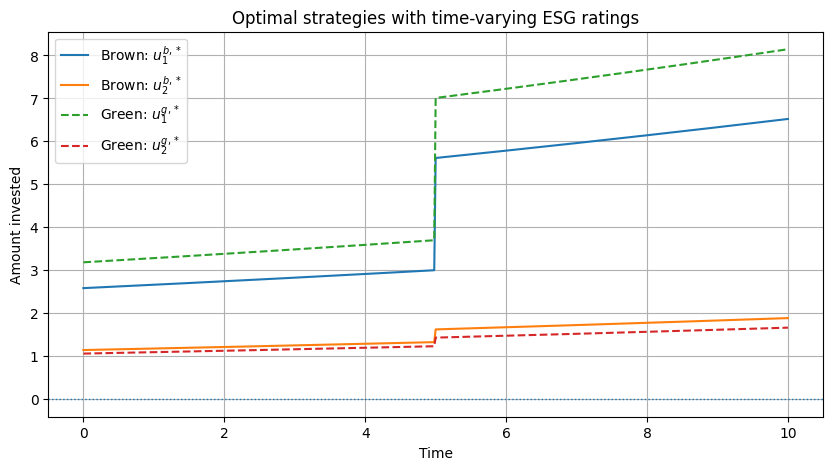

In [11]:
def scenario_time(t):
    if t < 5:
        G_t = np.array([0.5, -0.5])
        mu_t = np.array([0.08, 0.22])
    else:
        G_t = np.array([1, -1.0])
        mu_t = np.array([0.12, 0.27])

    theta_t = mu_t - r * np.ones(2)
    return G_t, theta_t


def optimal_u_timevarying(time, gamma1, gamma2, r, T, Sigma):
    Sigma_inv = np.linalg.inv(Sigma)

    u_b_values = []
    u_g_values = []

    for t in time:
        G_t, theta_t = scenario_time(t)

        u_b = ((1 / gamma1)* np.exp(-r * (T - t))* (Sigma_inv @ theta_t))

        u_g = ((1 / gamma1)* np.exp(-r * (T - t))* (Sigma_inv @ theta_t)
               + (gamma2 / gamma1**2)* np.exp(-r * (T - t))* (Sigma_inv @ G_t))

        u_b_values.append(u_b)
        u_g_values.append(u_g)

    return np.array(u_b_values), np.array(u_g_values)


u_b_tv, u_g_tv = optimal_u_timevarying(time, gamma1, gamma2, r, T, Sigma)

plt.figure(figsize=(10, 5))

plt.plot(time, u_b_tv[:, 0], label=r"Brown: $u_1^{b,*}$")
plt.plot(time, u_b_tv[:, 1], label=r"Brown: $u_2^{b,*}$")
plt.plot(time, u_g_tv[:, 0], linestyle="--", label=r"Green: $u_1^{g,*}$")
plt.plot(time, u_g_tv[:, 1], linestyle="--", label=r"Green: $u_2^{g,*}$")

plt.axhline(0, linestyle=":", linewidth=1)

plt.xlabel("Time")
plt.ylabel("Amount invested")
plt.title("Optimal strategies with time-varying ESG ratings")
plt.grid(True)
plt.legend()
plt.show()

Simulate for \pi instead of u.

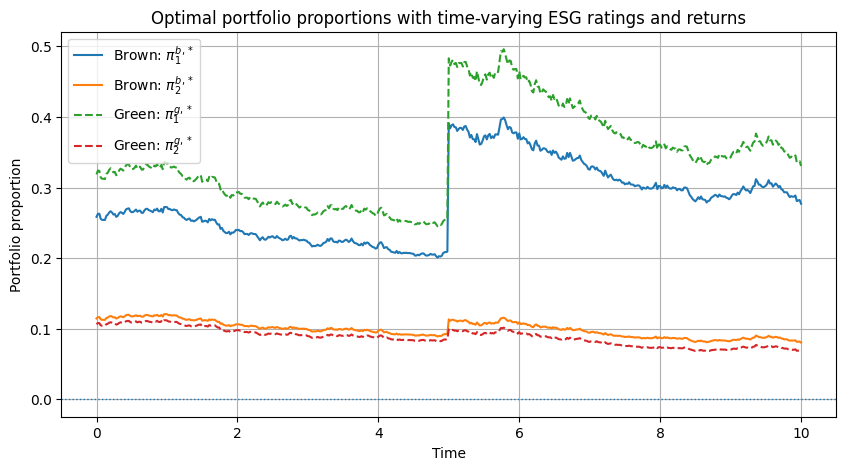

In [12]:
def simulate_wealth_timevarying(X0, sigma, gamma1, gamma2, Sigma, r, T, Ndt, Nsims=100):
    dt = T / Ndt
    time = np.linspace(0, T, Ndt + 1)

    X_b = np.zeros((Ndt + 1, Nsims))
    X_g = np.zeros((Ndt + 1, Nsims))

    X_b[0, :] = X0
    X_g[0, :] = X0

    Sigma_inv = np.linalg.inv(Sigma)

    u_b_values = np.zeros((Ndt + 1, 2))
    u_g_values = np.zeros((Ndt + 1, 2))

    for idx in range(Ndt):
        t = time[idx]

        G_t, theta_t = scenario_time(t)

        u_b = ((1 / gamma1)* np.exp(-r * (T - t))* (Sigma_inv @ theta_t))

        u_g = ((1 / gamma1)* np.exp(-r * (T - t))* (Sigma_inv @ theta_t)
               + (gamma2 / gamma1**2)* np.exp(-r * (T - t))* (Sigma_inv @ G_t))

        u_b_values[idx, :] = u_b
        u_g_values[idx, :] = u_g

        Z = np.random.randn(2, Nsims)
        dW = np.sqrt(dt) * Z

        X_b[idx + 1, :] = (X_b[idx, :]+ (r * X_b[idx, :] + u_b.T @ theta_t) * dt+ u_b.T @ sigma @ dW)

        X_g[idx + 1, :] = (X_g[idx, :]+ (r * X_g[idx, :] + u_g.T @ theta_t) * dt+ u_g.T @ sigma @ dW )

    # define u at final time as well
    G_T, theta_T = scenario_time(T)
    u_b_values[-1, :] = ((1 / gamma1) * np.exp(-r * (T - T))* (Sigma_inv @ theta_T) )

    u_g_values[-1, :] = ((1 / gamma1)* np.exp(-r * (T - T))* (Sigma_inv @ theta_T)
                         + (gamma2 / gamma1**2)* np.exp(-r * (T - T))* (Sigma_inv @ G_T))

    return time, X_b, X_g, u_b_values, u_g_values

np.random.seed(123)

time, X_b_tv, X_g_tv, u_b_tv, u_g_tv = simulate_wealth_timevarying(
    X0=X0,
    sigma=sigma,
    gamma1=gamma1,
    gamma2=gamma2,
    Sigma=Sigma,
    r=r,
    T=T,
    Ndt=Ndt,
    Nsims=Nsims
)

path = 0

pi_b_tv = u_b_tv / X_b_tv[:, path].reshape(-1, 1)
pi_g_tv = u_g_tv / X_g_tv[:, path].reshape(-1, 1)


plt.figure(figsize=(10, 5))

plt.plot(time, pi_b_tv[:, 0], label=r"Brown: $\pi_1^{b,*}$")
plt.plot(time, pi_b_tv[:, 1], label=r"Brown: $\pi_2^{b,*}$")
plt.plot(time, pi_g_tv[:, 0], linestyle="--", label=r"Green: $\pi_1^{g,*}$")
plt.plot(time, pi_g_tv[:, 1], linestyle="--", label=r"Green: $\pi_2^{g,*}$")


plt.axhline(0, linestyle=":", linewidth=1)

plt.xlabel("Time")
plt.ylabel("Portfolio proportion")
plt.title("Optimal portfolio proportions with time-varying ESG ratings and returns")
plt.grid(True)
plt.legend()
plt.show()